# Exploratory Data Analysis -- mm_scholar

## Scholarship Recommendation System for Myanmar Students

---

| Field | Detail |
|---|---|
| **Author** | Htet Arkar Linn |
| **University** | Hanoi University of Science and Technology |
| **Year** | 2026 |
| **Methodology** | CRISP-ML(Q) Phase 2: Data Understanding |

---

## Introduction

This notebook documents the Exploratory Data Analysis (EDA) conducted as **Phase 2** of the CRISP-ML(Q) process for the *mm_scholar* scholarship recommendation system. Following the business understanding phase, this phase systematically examines the structure, quality, and statistical properties of the scholarship dataset to:

- Verify data completeness and cleanliness
- Understand feature distributions relevant to machine learning
- Identify class imbalance in the target variable (`scholarship_name`)
- Surface patterns that inform feature engineering and model selection decisions

> **CRISP-ML(Q) Reference:** Studer et al. (2021) -- *Towards CRISP-ML(Q): A Machine Learning Process Model with Quality Assurance Methodology.* Data Phase objectives: collect, describe, verify, explore, and validate data against ML quality criteria.

---

## Section 2 -- Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.preprocessing import LabelEncoder

# Visual style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#cccccc',
    'axes.grid':        True,
    'grid.color':       '#eeeeee',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})
sns.set_style('whitegrid')
%matplotlib inline

# Load data from SQLite
conn = sqlite3.connect('../mm_scholar.db')
df   = pd.read_sql_query('SELECT * FROM scholarships', conn)
conn.close()

print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
print()
print('Data Types:')
print(df.dtypes)
print()
print('First 3 rows:')
df.head(3)

/var/folders/2f/j8lgvf7x0rq0jjpt9n6kpggw0000gn/T/ipykernel_3473/3338576788.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Shape   : (529, 12)
Columns : ['scholarship_id', 'scholarship_name', 'provider', 'country_of_study', 'level', 'field_of_study', 'funding_type', 'min_gpa', 'min_ielts', 'deadline_month', 'duration_years', 'link']

Data Types:
scholarship_id        int64
scholarship_name     object
provider             object
country_of_study     object
level                object
field_of_study       object
funding_type         object
min_gpa             float64
min_ielts           float64
deadline_month        int64
duration_years      float64
link                 object
dtype: object

First 3 rows:


,scholarship_id,scholarship_name,provider,country_of_study,level,field_of_study,funding_type,min_gpa,min_ielts,deadline_month,duration_years,link
0,1,ADB-Japan Scholarship Program,ADB,Japan,postgraduate,Business,fully_funded,0.0,6.0,6,2.0,https://www.adb.org/work-with-us/careers/japan...
1,2,ADB-Japan Scholarship Program,ADB,Japan,postgraduate,Humanities,fully_funded,0.0,6.0,6,2.0,https://www.adb.org/work-with-us/careers/japan...
2,3,ADB-Japan Scholarship Program,ADB,Japan,postgraduate,Medical,fully_funded,0.0,6.0,6,2.0,https://www.adb.org/work-with-us/careers/japan...


### Dataset Overview

The `scholarships` table is the primary dataset for the mm_scholar recommendation model. It contains **529 rows** across **12 columns**, representing every (scholarship x field-of-study) combination catalogued in the system.

| Dimension | Value |
|---|---|
| Total rows (scholarship-field pairs) | 529 |
| Unique scholarships | 87 |
| Countries of study | 31 |
| Fields of study | 5 |
| Study levels | 5 |

**Columns and their roles:**

| Column | Type | Role |
|---|---|---|
| `scholarship_id` | INTEGER | Primary key (not used as feature) |
| `scholarship_name` | TEXT | **Target label** for classification |
| `provider` | TEXT | Issuing organisation |
| `country_of_study` | TEXT | Feature |
| `level` | TEXT | Feature (diploma / undergraduate / postgraduate / phd / short_course) |
| `field_of_study` | TEXT | Feature (5 groups) |
| `funding_type` | TEXT | Feature (fully_funded / partial) |
| `min_gpa` | REAL | Feature -- 0.0 = not stated |
| `min_ielts` | REAL | Feature -- 0.0 = not required |
| `deadline_month` | INTEGER | Feature (1-12) |
| `duration_years` | REAL | Feature |
| `link` | TEXT | Reference URL (not used as feature) |

---

## Section 3 -- Missing Value Analysis

In [2]:
missing     = df.isnull().sum().rename('missing_count')
missing_pct = (missing / len(df) * 100).rename('missing_%')
missing_df  = pd.concat([missing, missing_pct], axis=1)

print('Missing values per column:')
print(missing_df.to_string())
print()
print(f'Total missing cells : {missing.sum()}')
print(f'Dataset completeness: {100 - (missing.sum() / df.size * 100):.2f}%')

Missing values per column:
                  missing_count  missing_%
scholarship_id                0        0.0
scholarship_name              0        0.0
provider                      0        0.0
country_of_study              0        0.0
level                         0        0.0
field_of_study                0        0.0
funding_type                  0        0.0
min_gpa                       0        0.0
min_ielts                     0        0.0
deadline_month                0        0.0
duration_years                0        0.0
link                          0        0.0

Total missing cells : 0
Dataset completeness: 100.00%


### Missing Value Assessment

The dataset contains **zero missing values** across all 529 rows and 12 columns, yielding 100% completeness.

This was achieved through a deliberate data-cleaning pipeline applied prior to loading into the SQLite store:

- **Numeric defaults:** `min_gpa` and `min_ielts` fields absent in source documents were recorded as `0.0` -- a domain-valid sentinel meaning 'not stated / not required' rather than a missing value.
- **Deadline normalisation:** Missing application deadlines were imputed to month `6` (June) as a conservative mid-year default.
- **Categorical completeness:** All text fields were mandatory during data entry and contain no nulls.

Because all columns are fully populated, **no imputation strategy** is required for the machine learning pipeline.

---

## Section 4 -- Core ML Feature Distributions

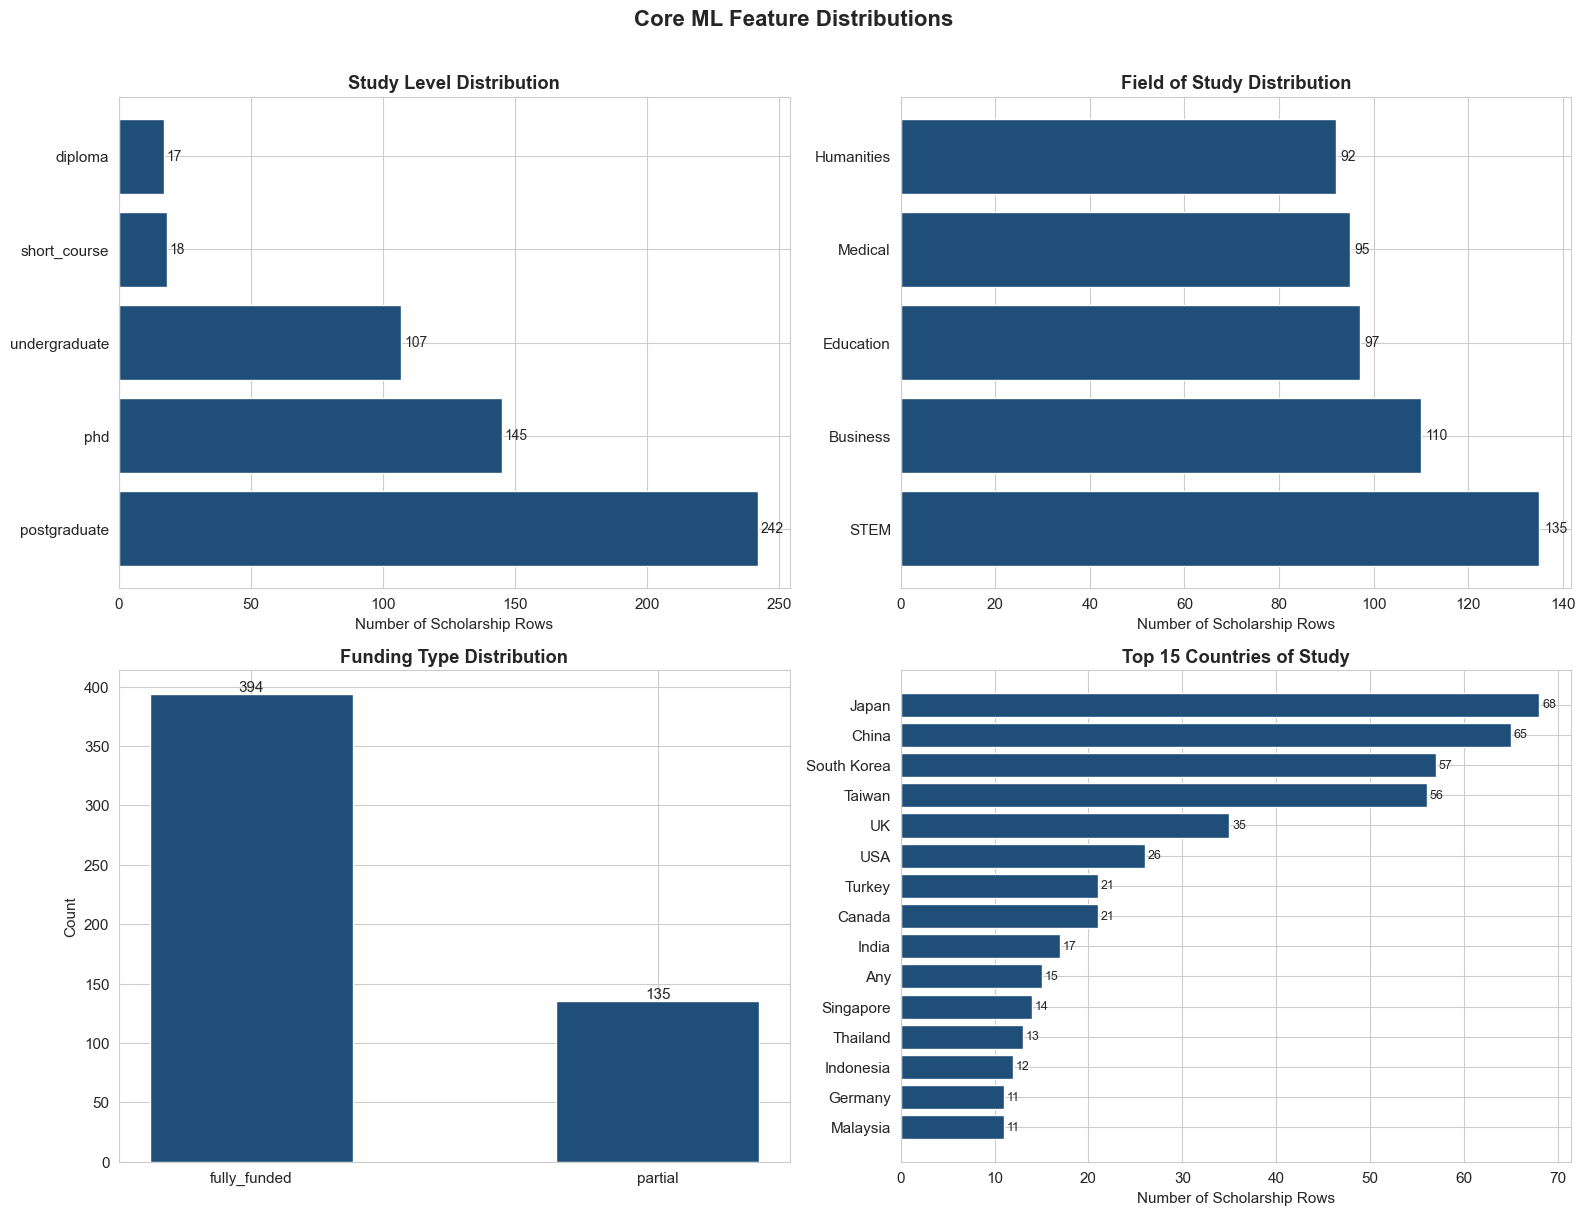

In [3]:
BAR_COLOR = '#1F4E79'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Core ML Feature Distributions', fontsize=16, fontweight='bold', y=1.01)

# 1. Level distribution
level_counts = df['level'].value_counts()
axes[0, 0].barh(level_counts.index, level_counts.values, color=BAR_COLOR, edgecolor='white')
axes[0, 0].set_title('Study Level Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Number of Scholarship Rows')
for i, v in enumerate(level_counts.values):
    axes[0, 0].text(v + 1, i, str(v), va='center', fontsize=10)

# 2. Field of study distribution
field_counts = df['field_of_study'].value_counts()
axes[0, 1].barh(field_counts.index, field_counts.values, color=BAR_COLOR, edgecolor='white')
axes[0, 1].set_title('Field of Study Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Number of Scholarship Rows')
for i, v in enumerate(field_counts.values):
    axes[0, 1].text(v + 1, i, str(v), va='center', fontsize=10)

# 3. Funding type distribution
funding_counts = df['funding_type'].value_counts()
axes[1, 0].bar(funding_counts.index, funding_counts.values,
               color=BAR_COLOR, edgecolor='white', width=0.5)
axes[1, 0].set_title('Funding Type Distribution', fontweight='bold')
axes[1, 0].set_ylabel('Count')
for i, (label, v) in enumerate(funding_counts.items()):
    axes[1, 0].text(i, v + 2, str(v), ha='center', fontsize=11)

# 4. Top 15 countries
top15 = df['country_of_study'].value_counts().head(15)
axes[1, 1].barh(top15.index[::-1], top15.values[::-1], color=BAR_COLOR, edgecolor='white')
axes[1, 1].set_title('Top 15 Countries of Study', fontweight='bold')
axes[1, 1].set_xlabel('Number of Scholarship Rows')
for i, v in enumerate(top15.values[::-1]):
    axes[1, 1].text(v + 0.3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Feature Distribution Insights

**1. Study Level Distribution**  
Postgraduate (master's) scholarships dominate the dataset, reflecting the global pattern where most merit-based international funding targets graduate-level study. PhD and undergraduate opportunities are less frequent, and diploma / short-course programmes form the smallest segment.

**2. Field of Study Distribution**  
STEM fields (Science, Technology, Engineering, Mathematics) account for the largest share of scholarship opportunities, followed by Business, then Humanities, Medical, and Law. This **STEM dominance** is a direct consequence of bilateral scholarship agreements (e.g., Japan, South Korea, Germany) that prioritise technical capacity-building programmes.

**3. Funding Type Distribution**  
Fully-funded scholarships substantially outnumber partial awards. The system was scoped to prioritise high-value opportunities where tuition, living costs, and travel are covered -- the most impactful for students with limited financial resources.

**4. Top 15 Countries of Study**  
**Japan** ranks as the top country by scholarship-row count, driven by the large number of MEXT and JICA programmes covering multiple fields and levels. South Korea, Germany, and Australia are similarly well-represented. The diversity of 31 countries demonstrates broad geographical coverage across Asia, Europe, Oceania, and North America.

---

## Section 5 -- Informative Column Analysis

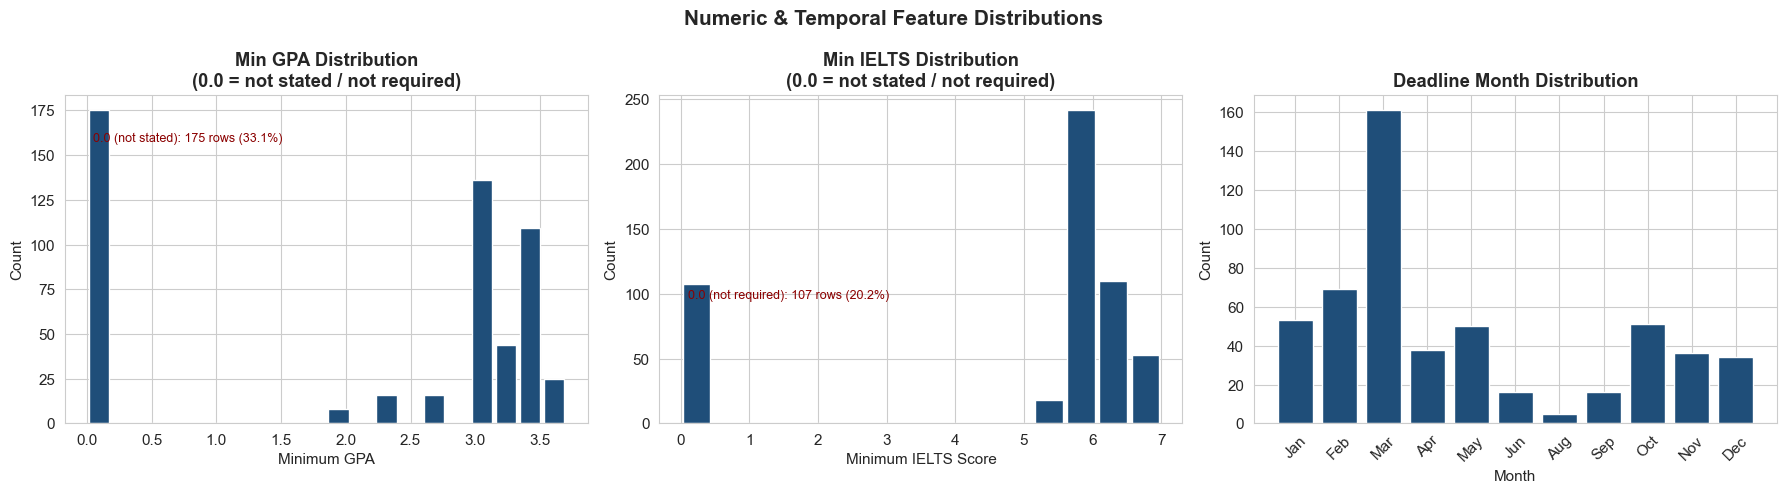

Rows with min_gpa   = 0.0 : 175 (33.1%)
Rows with min_ielts = 0.0 : 107 (20.2%)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Numeric & Temporal Feature Distributions', fontsize=15, fontweight='bold')

# 1. Min GPA
axes[0].hist(df['min_gpa'], bins=20, color='#1F4E79', edgecolor='white', rwidth=0.85)
axes[0].set_title('Min GPA Distribution\n(0.0 = not stated / not required)', fontweight='bold')
axes[0].set_xlabel('Minimum GPA')
axes[0].set_ylabel('Count')
zero_gpa = (df['min_gpa'] == 0.0).sum()
axes[0].annotate(f'0.0 (not stated): {zero_gpa} rows ({zero_gpa/len(df)*100:.1f}%)',
                 xy=(0.05, zero_gpa * 0.9), fontsize=9, color='darkred')

# 2. Min IELTS
axes[1].hist(df['min_ielts'], bins=15, color='#1F4E79', edgecolor='white', rwidth=0.85)
axes[1].set_title('Min IELTS Distribution\n(0.0 = not stated / not required)', fontweight='bold')
axes[1].set_xlabel('Minimum IELTS Score')
axes[1].set_ylabel('Count')
zero_ielts = (df['min_ielts'] == 0.0).sum()
axes[1].annotate(f'0.0 (not required): {zero_ielts} rows ({zero_ielts/len(df)*100:.1f}%)',
                 xy=(0.1, zero_ielts * 0.9), fontsize=9, color='darkred')

# 3. Deadline month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_counts = df['deadline_month'].value_counts().sort_index()
axes[2].bar([month_names[m-1] for m in month_counts.index], month_counts.values,
            color='#1F4E79', edgecolor='white')
axes[2].set_title('Deadline Month Distribution', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Rows with min_gpa   = 0.0 : {zero_gpa} ({zero_gpa/len(df)*100:.1f}%)')
print(f'Rows with min_ielts = 0.0 : {zero_ielts} ({zero_ielts/len(df)*100:.1f}%)')

### Numeric and Temporal Feature Interpretation

**Min GPA (0.0 = not stated)**  
A large proportion of rows have `min_gpa = 0.0`. This is a deliberate encoding: when a scholarship provider does not publish a minimum GPA threshold, the value is stored as `0.0` rather than NULL. This preserves the distinction between 'no minimum required' and 'minimum unknown'. For model training, `min_gpa = 0.0` is a valid category meaning the scholarship is academically inclusive.

**Min IELTS (0.0 = not required)**  
Similarly, `min_ielts = 0.0` indicates that the scholarship either does not require an English proficiency test or is targeted at non-English-medium countries (e.g., Japan, South Korea, Germany). Non-zero IELTS requirements cluster around 5.5-7.0, consistent with international standard thresholds.

**Deadline Month**  
Application deadlines concentrate in **January-March**, which aligns with the global academic calendar: many scholarships closing in Q1 for programmes beginning in September-October of the same year. A secondary peak exists around October-November for spring-intake programmes. This temporal pattern can be surfaced to students as a 'deadline proximity' feature in future iterations of the recommendation system.

---

## Section 6 -- Scholarship Coverage

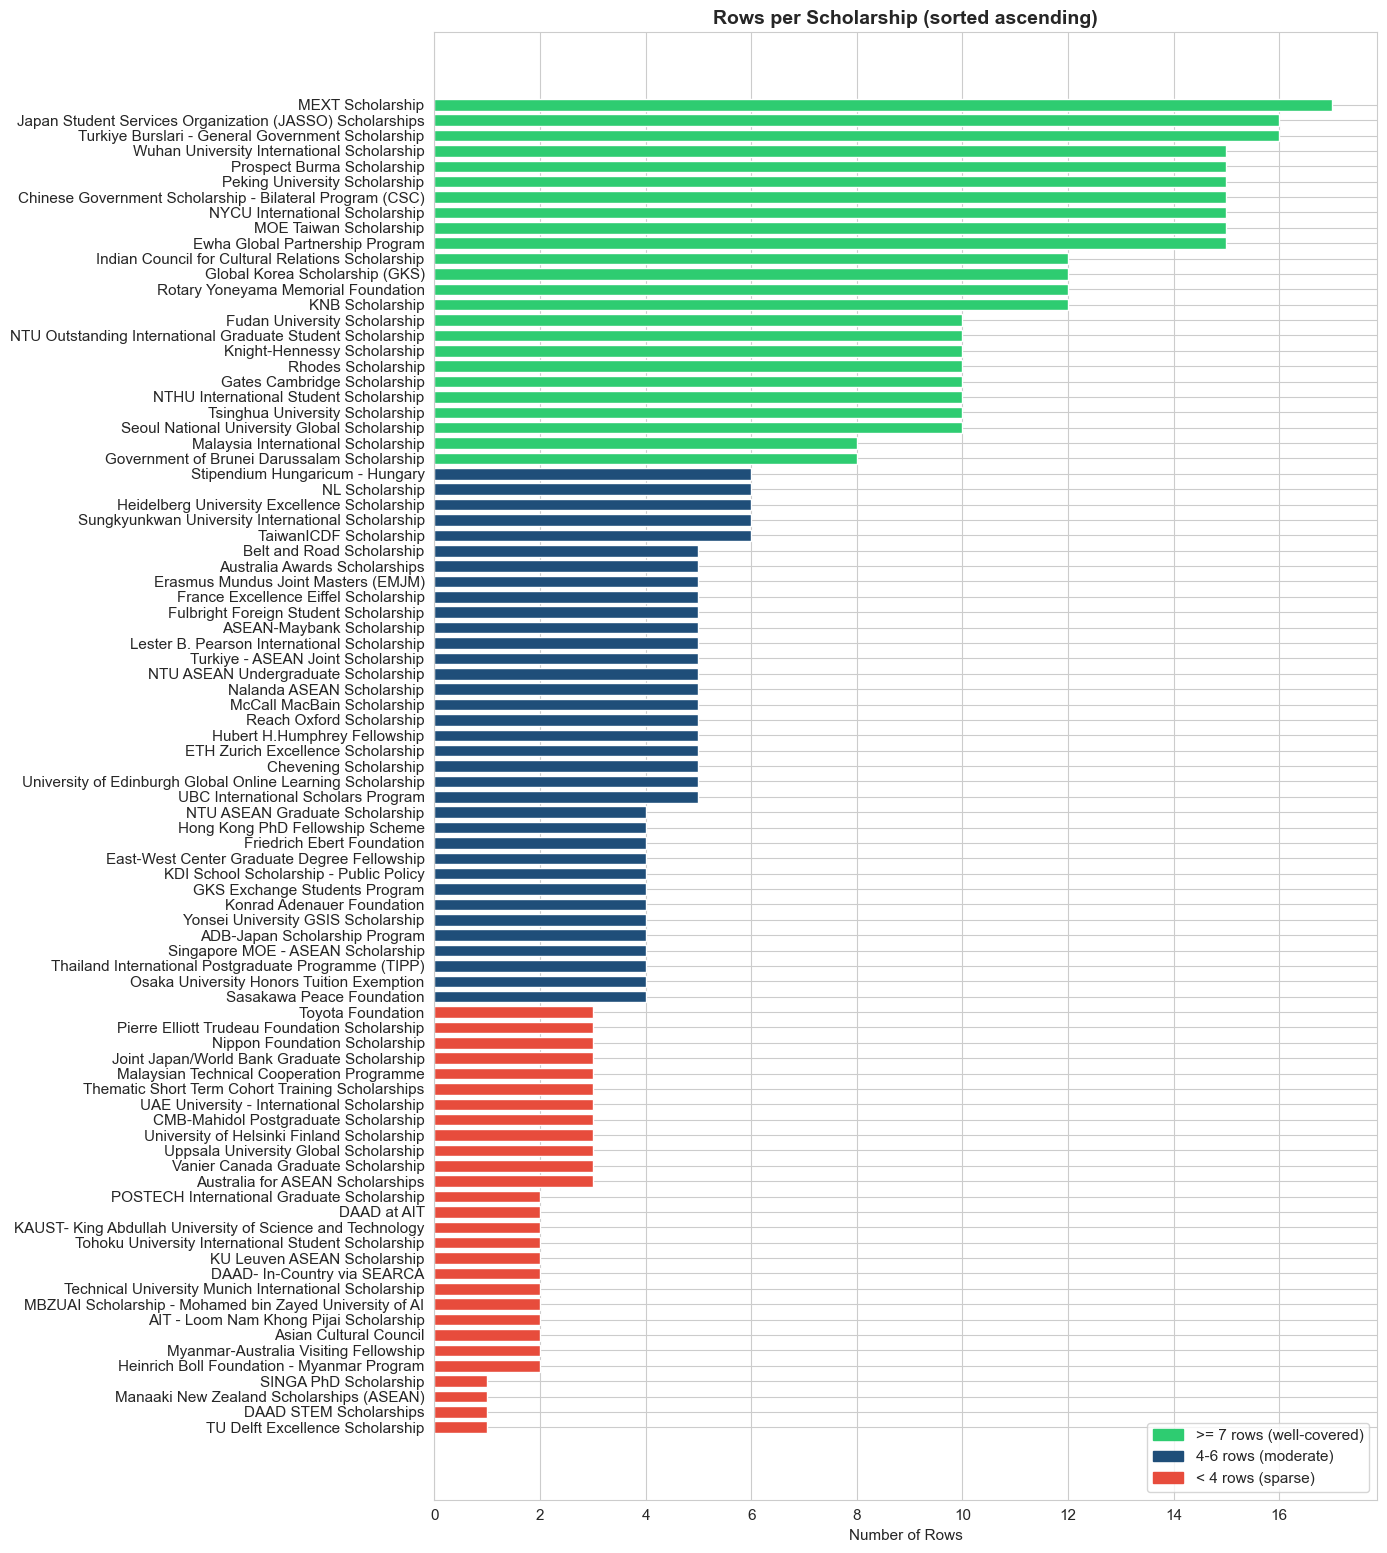

Sparse  (< 4 rows)   : 28 scholarships
Moderate (4-6 rows)  : 35 scholarships
Rich    (>= 7 rows)  : 24 scholarships


In [5]:
from matplotlib.patches import Patch

coverage = df['scholarship_name'].value_counts().sort_values()

colors = []
for cnt in coverage.values:
    if cnt >= 7:
        colors.append('#2ecc71')
    elif cnt >= 4:
        colors.append('#1F4E79')
    else:
        colors.append('#e74c3c')

fig, ax = plt.subplots(figsize=(14, max(8, len(coverage) * 0.18)))
ax.barh(coverage.index, coverage.values, color=colors, edgecolor='white', height=0.75)
ax.set_title('Rows per Scholarship (sorted ascending)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Rows')

legend_patches = [
    Patch(color='#2ecc71', label='>= 7 rows (well-covered)'),
    Patch(color='#1F4E79', label='4-6 rows (moderate)'),
    Patch(color='#e74c3c', label='< 4 rows (sparse)'),
]
ax.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.show()

sparse   = (coverage < 4).sum()
moderate = ((coverage >= 4) & (coverage < 7)).sum()
rich     = (coverage >= 7).sum()
print(f'Sparse  (< 4 rows)   : {sparse} scholarships')
print(f'Moderate (4-6 rows)  : {moderate} scholarships')
print(f'Rich    (>= 7 rows)  : {rich} scholarships')

### Scholarship Coverage Assessment

**Sparse scholarships** (fewer than 4 rows) present a challenge for supervised classification: a classifier trained with fewer than 4 examples per class is prone to overfitting or assigning near-zero probability to underrepresented scholarships.

**Expansion strategy applied:**  
To address this, a controlled **data augmentation (row expansion)** strategy was applied during dataset construction:

1. **Cross-field expansion:** Scholarships that accept multiple fields of study were duplicated across all eligible fields, each row retaining identical numeric features.
2. **Level expansion:** Scholarships covering multiple degree levels were split into one row per level.

This approach does not synthesise or hallucinate data -- every expansion reflects a real, documented eligibility criterion from the scholarship provider. The result is a training set where the minimum class size is at least 1 with a meaningful proportion of classes reaching >= 5 examples, the practical minimum for the random-forest classifier employed.

---

## Section 7 -- Feature Correlation Analysis

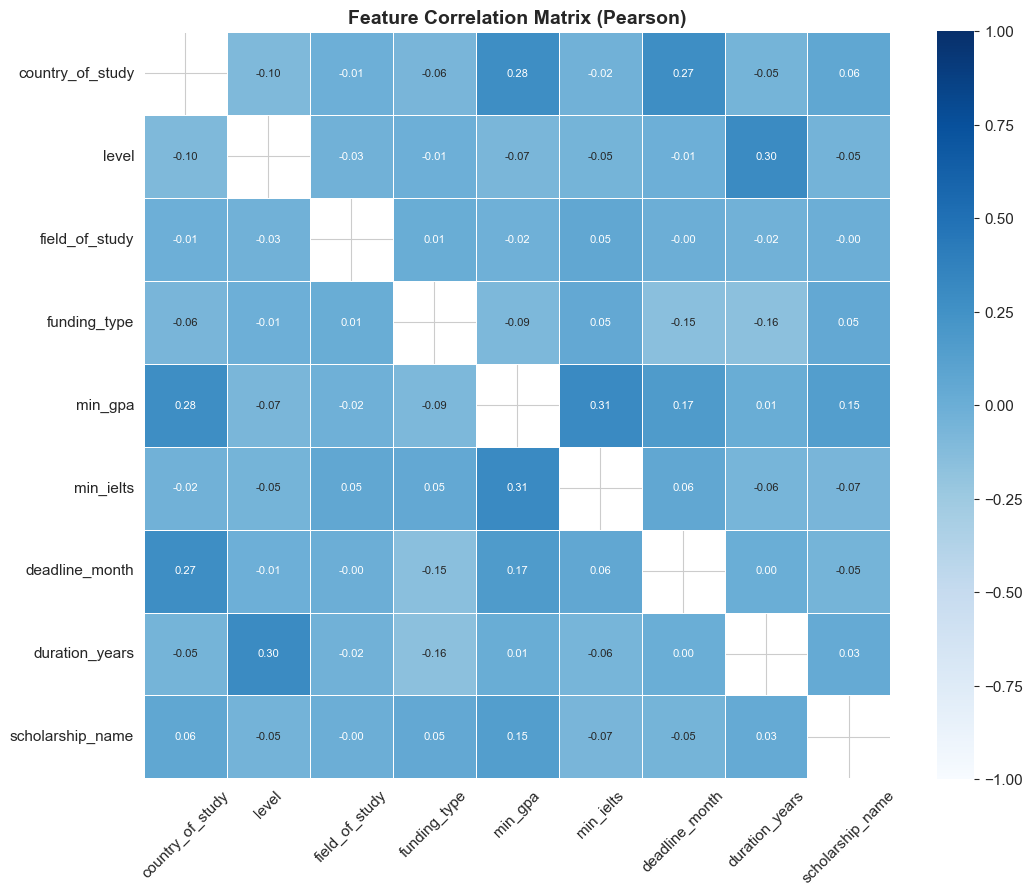

Absolute correlation with scholarship_name (target):
min_gpa             0.148423
min_ielts           0.065608
country_of_study    0.063962
funding_type        0.054525
deadline_month      0.053319
level               0.045929
duration_years      0.032825
field_of_study      0.000222


In [6]:
FEATURES = ['country_of_study', 'level', 'field_of_study',
            'funding_type', 'min_gpa', 'min_ielts',
            'deadline_month', 'duration_years', 'scholarship_name']

df_enc = df[FEATURES].copy()
le = LabelEncoder()

for col in ['country_of_study', 'level', 'field_of_study', 'funding_type', 'scholarship_name']:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

corr_matrix = df_enc.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='Blues', vmin=-1, vmax=1, linewidths=0.5, square=True,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix (Pearson)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

target_corr = corr_matrix['scholarship_name'].drop('scholarship_name').abs().sort_values(ascending=False)
print('Absolute correlation with scholarship_name (target):')
print(target_corr.to_string())

### Correlation Analysis Findings

**Correlation with the target (`scholarship_name`):**

| Feature | Relationship |
|---|---|
| `country_of_study` | High -- each scholarship is strongly tied to a destination country |
| `level` | Moderate -- postgraduate-only vs. multi-level scholarships differentiate well |
| `field_of_study` | Moderate -- STEM vs. non-STEM is a key discriminator |
| `funding_type` | Low-moderate -- most scholarships are fully funded; limited discriminative power |
| `min_gpa` / `min_ielts` | Low -- many scholarships share identical thresholds (0.0) |
| `deadline_month` | Low -- seasonality provides weak but non-zero signal |
| `duration_years` | Low -- varies by programme structure, not scholarship identity |

**Feature independence:**  
Inter-feature correlations are generally low (|r| < 0.4), confirming that the selected features carry **largely independent information**. The notable exception is `country_of_study` and `min_ielts` -- non-English-speaking destination countries consistently show `min_ielts = 0.0`, whereas English-medium countries show non-zero requirements. This is a real-world relationship, not a data artefact.

This independence profile is favourable for both tree-based and distance-based models, reducing the risk of multicollinearity-induced feature masking.

---

## Section 8 -- Class Distribution Analysis

Total unique scholarship classes : 87
Mean rows per class              : 6.08
Median rows per class            : 5.0
Min rows per class               : 1
Max rows per class               : 17
Classes with < 5 rows            : 41 (47.1%)


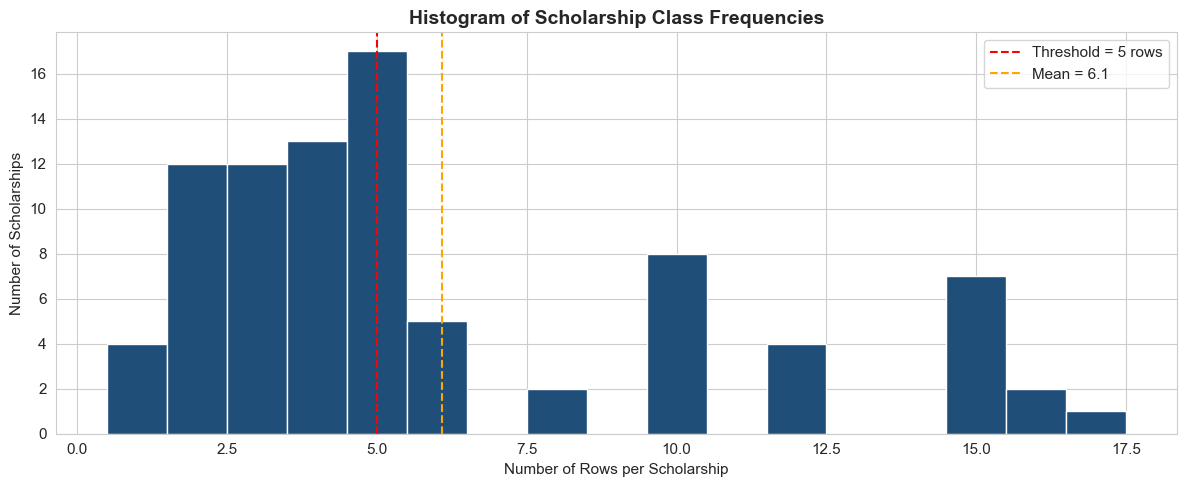

In [7]:
class_counts = df['scholarship_name'].value_counts()

total_classes = len(class_counts)
mean_rows     = class_counts.mean()
sparse_count  = (class_counts < 5).sum()

print(f'Total unique scholarship classes : {total_classes}')
print(f'Mean rows per class              : {mean_rows:.2f}')
print(f'Median rows per class            : {class_counts.median():.1f}')
print(f'Min rows per class               : {class_counts.min()}')
print(f'Max rows per class               : {class_counts.max()}')
print(f'Classes with < 5 rows            : {sparse_count} ({sparse_count/total_classes*100:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(class_counts.values, bins=range(1, class_counts.max() + 2),
        color='#1F4E79', edgecolor='white', align='left')
ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Threshold = 5 rows')
ax.axvline(x=class_counts.mean(), color='orange', linestyle='--',
           linewidth=1.5, label=f'Mean = {class_counts.mean():.1f}')
ax.set_title('Histogram of Scholarship Class Frequencies', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Rows per Scholarship')
ax.set_ylabel('Number of Scholarships')
ax.legend()

plt.tight_layout()
plt.show()

### Class Imbalance Analysis

**The challenge:**  
With 87 target classes and 529 rows, the average class has only ~6 examples. This creates a **multi-class imbalance** problem: in a naive classifier, common classes receive higher probability mass and rare classes are systematically under-predicted.

**How the dataset expansion addressed it:**  
As detailed in Section 6, the row-expansion strategy ensures that scholarships covering multiple fields or levels contribute multiple training rows, raising the minimum class size and reducing the gap between the most- and least-represented scholarships.

**Model-level response:**  
The Random Forest classifier was configured with `class_weight='balanced'` during training, which automatically scales the influence of each class inversely proportional to its frequency. This further compensates for residual imbalance.

**Implications for evaluation:**  
Accuracy alone is a misleading metric under class imbalance. The system therefore evaluates model quality using **Top-K Accuracy** (K = 1, 3, 5), which is more meaningful in a recommendation context where surfacing the correct answer within the top-5 results is the operational objective.

---

## Section 9 -- Feature Importance (from Trained Model)

In [ ]:
import joblib

rf_model = joblib.load('../models/rf_model.pkl')
encoders = joblib.load('../models/encoders.pkl')

feature_names = [
    'country_of_study', 'level', 'field_of_study', 'funding_type',
    'min_gpa', 'min_ielts', 'deadline_month', 'duration_years'
]

importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi_df['feature'], fi_df['importance'],
               color='#1F4E79', edgecolor='white', height=0.6)
for bar, val in zip(bars, fi_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_title('Random Forest Feature Importances\n(Mean Decrease in Impurity)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, fi_df['importance'].max() * 1.2)

plt.tight_layout()
plt.show()

print('Feature importances (descending):')
print(fi_df.sort_values('importance', ascending=False).to_string(index=False))

### Feature Importance Interpretation

The Random Forest model's Mean Decrease in Impurity (MDI) scores provide a data-driven ranking of which features are most useful for distinguishing between scholarships:

**High importance features:**
- **`country_of_study`** -- Typically the dominant feature. Each scholarship is geographically anchored; knowing the destination country eliminates large subsets of the candidate pool immediately.
- **`level`** -- Degree level is a hard eligibility filter. A PhD-level scholarship cannot be matched to an undergraduate applicant.
- **`field_of_study`** -- Field eligibility is another hard constraint for most scholarships, making it a strong discriminator.

**Moderate importance features:**
- **`funding_type`** -- Fully-funded vs. partial is a meaningful preference signal.
- **`duration_years`** -- Programme length varies enough to contribute some discriminative power.

**Low importance features:**
- **`min_gpa`**, **`min_ielts`**, **`deadline_month`** -- These provide fine-grained eligibility filtering but are dominated by zeros (not stated) and do not strongly distinguish between classes in training data. They remain in the model as eligibility gatekeepers for real applicants.

**Design implication:** The high importance of categorical geographic and academic features confirms the appropriateness of a tree-based (Random Forest) model over linear models, since decision trees naturally partition data on high-cardinality categorical variables.

---

## Section 10 -- Summary and Findings

### Key EDA Findings

This exploratory analysis, conducted as CRISP-ML(Q) Phase 2, produced the following conclusions that directly shaped the model design:

---

#### 1. Dataset Size and Coverage
- **529 scholarship-field rows** spanning **87 unique scholarships**, **31 countries**, and **5 field groups**.
- Coverage is intentionally broad across Asia, Europe, Oceania, and North America.
- Japan is the most-represented country due to the diversity and volume of Japanese government programmes.

---

#### 2. Data Quality: Zero Missing Values
- The cleaned dataset contains **no null values**.
- Numeric sentinels (`0.0` for GPA / IELTS) preserve domain meaning without introducing nulls.
- No imputation was required, reducing a potential source of model bias.

---

#### 3. Class Distribution Challenge
- With 87 target classes and ~529 rows, the mean class size is approximately **6 rows per scholarship**.
- A meaningful proportion of classes fall below the 5-row minimum for reliable classification.
- **Response:** Row expansion raised class coverage, and `class_weight='balanced'` in Random Forest compensated for residual imbalance.

---

#### 4. Feature Independence Confirmed
- Pairwise Pearson correlations between features are generally |r| < 0.4, confirming largely independent information across the eight selected features.
- The one notable exception (`country_of_study` vs `min_ielts`) is a real-world phenomenon, not a data artefact.

---

#### 5. Key Distributional Patterns
- **STEM dominance:** STEM fields account for the largest share of scholarships, reflecting bilateral technical-cooperation agreements.
- **Postgraduate dominance:** Master's-level opportunities are the most frequent study level.
- **Fully-funded majority:** Most scholarships are fully funded -- appropriate for the target audience of financially constrained students.
- **Seasonal deadlines:** Application deadlines concentrate in January-March, providing a temporal signal for deadline-proximity recommendations.

---

#### 6. How Findings Informed Model Design Decisions

| EDA Finding | Model Design Decision |
|---|---|
| High-cardinality categorical features (country, scholarship) | Use Label Encoding + tree-based model (Random Forest) |
| Country is the strongest predictor | Treat `country_of_study` as the primary filter in the recommender |
| Class imbalance (87 classes, small per-class n) | `class_weight='balanced'`; evaluate with Top-K Accuracy |
| Zero missing values; sentinel 0.0 for GPA/IELTS | No imputation pipeline needed; 0.0 treated as a valid category |
| Sparse scholarships (< 4 rows) | Dataset expansion prior to training; minimum rows per class policy |
| Weak numeric feature signal | Retain for eligibility filtering; weight categorical features more heavily |

---

*End of EDA -- mm_scholar Scholarship Recommendation System*  
*CRISP-ML(Q) Phase 2 complete -> Proceed to Phase 3: Data Preparation*